In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import scipy.sparse as sp
from implicit.als import AlternatingLeastSquares
import umap

## оставляем только тех, у кого больше 1 отзыва

In [9]:
df = pd.read_csv('steam_reviews.csv')
df

,user_id,game_id,voted_up,playtime_at_review
0,76561198318574261,500,1,256.0
1,76561198783133953,500,1,88.0
2,76561199198666356,500,1,10.0
3,76561198137902025,500,1,307.0
4,76561198023590229,500,1,60.0
...,...,...,...,...
8572,76561198043388752,257510,1,1066.0
8573,76561198329474499,257510,1,2108.0
8574,76561198234546328,236870,0,3764.0
8575,76561197963366821,236870,0,1927.0


In [14]:
df_filtered = df.copy()

while True:
    old_len = len(df_filtered)

    df_filtered = df_filtered[
        df_filtered.groupby("user_id")["user_id"].transform("count") > 1
    ]

    df_filtered = df_filtered[
        df_filtered.groupby("game_id")["game_id"].transform("count") > 1
    ]

    if len(df_filtered) == old_len:
        break
df = df_filtered

In [11]:
pos_counts = df[df["voted_up"] == 1].groupby("user_id").size()
valid_users = pos_counts[pos_counts >= 2].index
df = df[df["user_id"].isin(valid_users)].copy()

## анализ датасета

In [15]:
df['user_id'].value_counts()

,count
user_id,
76561198077871807,43
76561198856659405,30
76561198078059329,28
76561197970839551,24
76561198365592244,19
...,...
76561198981319411,2
76561199385525167,2
76561199054237135,2


In [16]:
df['game_id'].value_counts()

,count
game_id,
900883,73
22330,71
34330,68
201270,66
130,58
...,...
899770,2
50130,2
466560,2


In [17]:
mean_users = df['user_id'].value_counts().mean()
mean_games = df['game_id'].value_counts().mean()

print(f'mean users: {mean_users}')
print(f'mean games: {mean_games}')

mean users: 2.705171762929407
mean games: 10.050490883590463


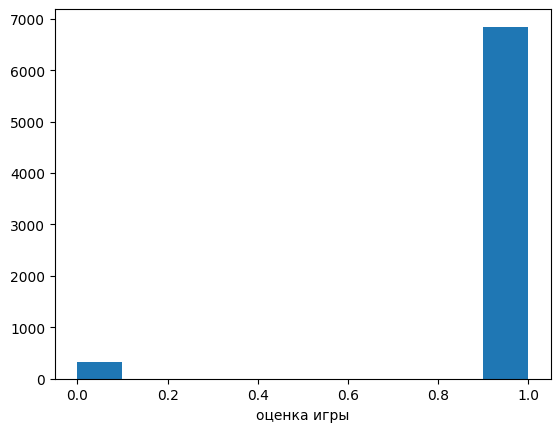

In [18]:
plt.hist(df['voted_up'])
plt.xlabel('оценка игры')
plt.show()

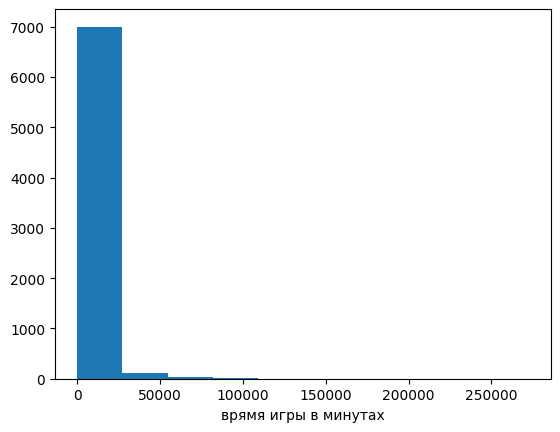

In [19]:
plt.hist(df['playtime_at_review'])
plt.xlabel('врямя игры в минутах')
plt.show()

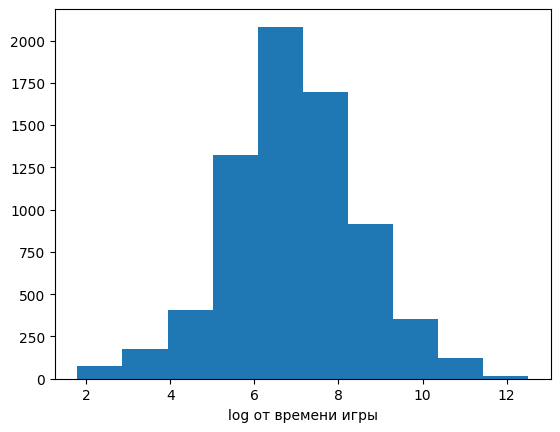

In [20]:
df["playtime_log"] = np.log1p(df["playtime_at_review"])
plt.hist(df["playtime_log"])
plt.xlabel("log от времени игры")
plt.show()

## Baseline

In [59]:
baseline = (
    df
    .assign(weighted_like=df["voted_up"] * df["playtime_log"])
    .groupby("game_id")["weighted_like"]
    .sum()
    .sort_values(ascending=False)
)

popular_games = baseline.index.tolist()

In [57]:
popular_games[:10]

[34330, 201270, 900883, 22330, 12210, 901583, 130, 50, 200260, 208650]

## user-item train-test сплит

In [24]:
positive_df = df[df["voted_up"] == 1]

test_idx = (
    positive_df
    .groupby("user_id", group_keys=False)
    .sample(n=1, random_state=42)
    .index
)

test_df = df.loc[test_idx].copy()
train_df = df.drop(index=test_idx).copy()

In [28]:
train_items = set(train_df["game_id"].unique())
test_df = test_df[test_df["game_id"].isin(train_items)].copy()
test_df

,user_id,game_id,voted_up,playtime_at_review,playtime_log
3010,76561197960303714,4500,1,1239.0,7.122867
5198,76561197960456257,1213210,1,305.0,5.723585
3341,76561197960643144,1794680,1,1556.0,7.350516
5819,76561197961082020,304240,1,2062.0,7.631917
7564,76561197961102437,19900,1,4311.0,8.369157
...,...,...,...,...,...
2524,76561199888771157,201270,1,978.0,6.886532
2182,76561199889014253,750920,1,520.0,6.255750
2115,76561199889306897,218620,1,613.0,6.419995
4623,76561199890367296,413150,1,2313.0,7.746733


In [29]:
test_users = set(test_df["user_id"].unique())
train_df = train_df[train_df["user_id"].isin(test_users)].copy()
train_df = train_df[train_df["voted_up"] == 1].copy()
train_df

,user_id,game_id,voted_up,playtime_at_review,playtime_log
0,76561198318574261,500,1,256.0,5.549076
2,76561199198666356,500,1,10.0,2.397895
3,76561198137902025,500,1,307.0,5.730100
4,76561198023590229,500,1,60.0,4.110874
7,76561198780374635,500,1,569.0,6.345636
...,...,...,...,...,...
8566,76561198098176839,10,1,1095.0,6.999422
8570,76561198078059329,257510,1,1706.0,7.442493
8571,76561198163023210,257510,1,17.0,2.890372
8572,76561198043388752,257510,1,1066.0,6.972606


# Alternating Least Squares

In [33]:
all_users = sorted(train_df["user_id"].unique())
all_items = sorted(train_df["game_id"].unique())

user_to_idx = {user_id: idx for idx, user_id in enumerate(all_users)}
item_to_idx = {game_id: idx for idx, game_id in enumerate(all_items)}

idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
idx_to_item = {idx: game_id for game_id, idx in item_to_idx.items()}

train_df["user_idx"] = train_df["user_id"].map(user_to_idx)
train_df["item_idx"] = train_df["game_id"].map(item_to_idx)


test_df["user_idx"] = test_df["user_id"].map(user_to_idx)
test_df["item_idx"] = test_df["game_id"].map(item_to_idx)

n_users = len(user_to_idx)
n_items = len(item_to_idx)

print("users:", n_users)
print("items:", n_items)

users: 2615
items: 686


In [35]:
train_df['confidence'] = 1 + train_df['playtime_log'] / train_df['playtime_log'].mean()
train_df["confidence"].describe()

,confidence
count,4151.000000
mean,2.000000
std,0.223681
min,1.279307
25%,1.860704
50%,1.995891
75%,2.141332
max,2.796294


In [41]:
user_item_matrix = sp.coo_matrix(
    (train_df['confidence'], (train_df['user_idx'], train_df['item_idx'])),
    shape=(n_users, n_items)
).tocsr()
user_item_matrix

<2615x686 sparse matrix of type '<class 'numpy.float64'>'
	with 4151 stored elements in Compressed Sparse Row format>

In [42]:
model = AlternatingLeastSquares(
    factors=32,
    regularization=0.05,
    alpha=1.0,
    iterations=30,
    random_state=42
)

model.fit(user_item_matrix)

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/30 [00:00<?, ?it/s]

In [47]:
user_embeddings

array([[ 1.6078381e-01,  4.2774975e-02, -1.6642156e-01, ...,
         8.4655501e-02,  3.7582420e-02,  1.6122916e-01],
       [-1.2394299e-01,  7.2638176e-02,  1.7115703e-02, ...,
         2.8224560e-02, -1.3241672e-02,  5.7556979e-02],
       [ 1.2939715e-01, -2.7621305e-02,  2.3158498e-02, ...,
        -5.0887015e-02,  2.3985600e-02,  6.5549709e-02],
       ...,
       [-2.4644678e-02,  3.2460365e-02,  1.4279611e-02, ...,
         2.9589410e-03,  1.0153588e-02, -3.0444162e-02],
       [ 3.2447034e-03,  5.7884930e-03, -4.3910807e-03, ...,
         5.1954882e-03,  2.5603627e-03, -3.5346773e-05],
       [ 8.2166485e-02,  6.8713933e-02, -8.0873244e-02, ...,
        -2.8940754e-02,  1.5723681e-02, -6.7804959e-03]], dtype=float32)

In [44]:
def recommend_for_user(user_id, model, user_item_matrix, user_to_idx, idx_to_item, k=10):
    user_idx = user_to_idx[user_id]

    item_indices, scores = model.recommend(
        userid=user_idx,
        user_items=user_item_matrix[user_idx],
        N=k,
        filter_already_liked_items=True
    )

    recommendations = [
        (idx_to_item[item_idx], score)
        for item_idx, score in zip(item_indices, scores)
    ]

    return recommendations

In [45]:
some_user = test_df["user_id"].iloc[0]

recommend_for_user(
    some_user,
    model,
    user_item_matrix,
    user_to_idx,
    idx_to_item,
    k=10
)

[(np.int64(500), np.float32(0.3705036)),
 (np.int64(201270), np.float32(0.3067142)),
 (np.int64(391220), np.float32(0.23051873)),
 (np.int64(250900), np.float32(0.21831758)),
 (np.int64(601150), np.float32(0.17384043)),
 (np.int64(412020), np.float32(0.17077616)),
 (np.int64(460790), np.float32(0.16523302)),
 (np.int64(1593500), np.float32(0.14867759)),
 (np.int64(367500), np.float32(0.14554462)),
 (np.int64(219740), np.float32(0.14408942))]

## визуализация эмбеддингов

In [51]:
user_embeddings = model.user_factors
item_embeddings = model.item_factors

print(user_embeddings.shape)
print(item_embeddings.shape)

(2615, 32)
(686, 32)


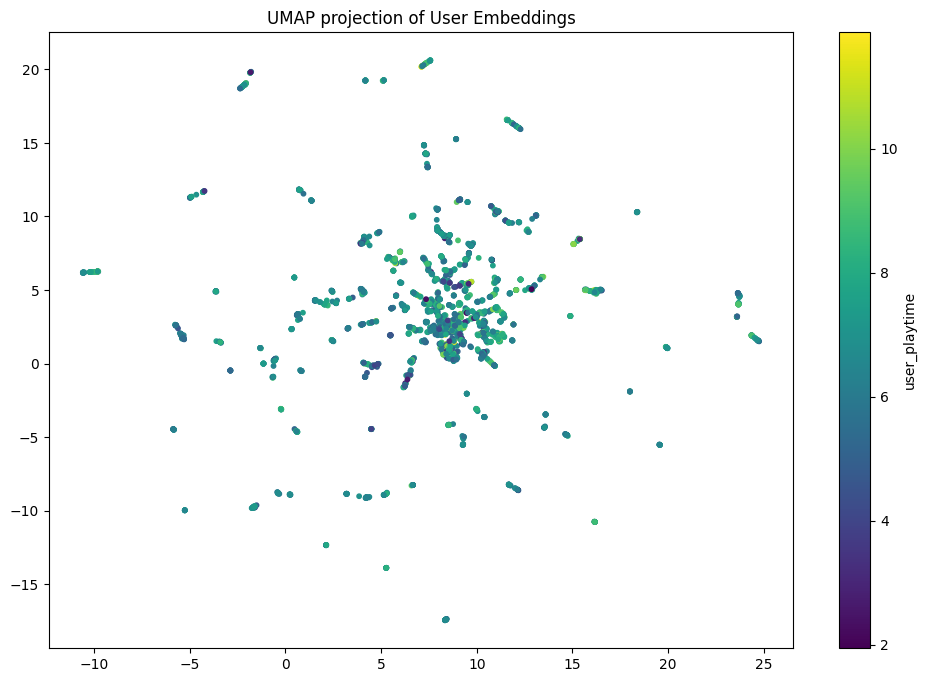

In [86]:
user_playtime = train_df.groupby("user_idx")["playtime_log"].mean()

user_colors = np.array([user_playtime.get(i, 0) for i in range(n_users)])

reducer = umap.UMAP(n_components=2)
embedding_2d = reducer.fit_transform(user_embeddings)
plt.figure(figsize=(12, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=10, c=user_colors)
plt.colorbar(label="user playtime")
plt.title('UMAP projection of User Embeddings')
plt.show()

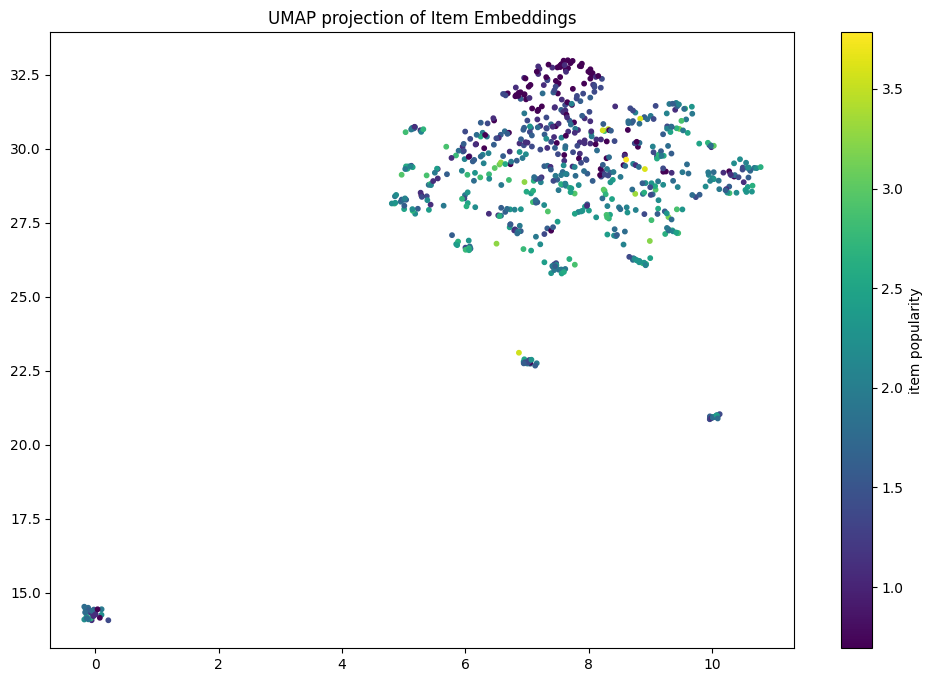

In [80]:
item_popularity = train_df.groupby("item_idx").size()

item_colors = np.array([
    item_popularity.get(i, 0)
    for i in range(n_items)
])

reducer = umap.UMAP(n_components=2)
embedding_2d = reducer.fit_transform(item_embeddings)
plt.figure(figsize=(12, 8))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=10, c=np.log1p(item_colors))
plt.colorbar(label="item popularity")
plt.title('UMAP projection of Item Embeddings')
plt.show()

## Сравнение с baseline

In [58]:
def precision_at_k(recommended_items, true_items, k):
    recommended_items = recommended_items[:k]
    true_items = set(true_items)

    if len(recommended_items) == 0:
        return 0.0

    hits = sum(item in true_items for item in recommended_items)
    return hits / k


def recall_at_k(recommended_items, true_items, k):
    recommended_items = recommended_items[:k]
    true_items = set(true_items)

    if len(true_items) == 0:
        return 0.0

    hits = sum(item in true_items for item in recommended_items)
    return hits / len(true_items)


def hitrate_at_k(recommended_items, true_items, k):
    recommended_items = recommended_items[:k]
    true_items = set(true_items)

    return float(any(item in true_items for item in recommended_items))


def ndcg_at_k(recommended_items, true_items, k):
    recommended_items = recommended_items[:k]
    true_items = set(true_items)

    dcg = 0.0
    for rank, item in enumerate(recommended_items, start=1):
        if item in true_items:
            dcg += 1.0 / np.log2(rank + 1)

    ideal_hits = min(len(true_items), k)
    idcg = sum(1.0 / np.log2(rank + 1) for rank in range(1, ideal_hits + 1))

    if idcg == 0:
        return 0.0

    return dcg / idcg

In [62]:
base = baseline.index.tolist()

train_items_by_user = (
    train_df
    .groupby("user_id")["game_id"]
    .apply(set)
    .to_dict()
)

test_items_by_user = (
    test_df
    .groupby("user_id")["game_id"]
    .apply(list)
    .to_dict()
)

len(test_items_by_user)

2615

In [67]:
def top_k(user_id, popular_items, train_items_by_user, k=10):
    seen_items = train_items_by_user.get(user_id, set())

    recs = []
    for item in popular_items:
        if item not in seen_items:
            recs.append(item)

        if len(recs) == k:
            break

    return recs

In [68]:
def evaluate_popularity(test_items_by_user, popular_items, train_items_by_user, k=10):
    precision_scores = []
    recall_scores = []
    hitrate_scores = []
    ndcg_scores = []

    for user_id, true_items in test_items_by_user.items():
        recommended_items = top_k(
            user_id,
            popular_items,
            train_items_by_user,
            k=k
        )

        precision_scores.append(precision_at_k(recommended_items, true_items, k))
        recall_scores.append(recall_at_k(recommended_items, true_items, k))
        hitrate_scores.append(hitrate_at_k(recommended_items, true_items, k))
        ndcg_scores.append(ndcg_at_k(recommended_items, true_items, k))

    return {
        f"Precision@{k}": np.mean(precision_scores),
        f"Recall@{k}": np.mean(recall_scores),
        f"HitRate@{k}": np.mean(hitrate_scores),
        f"NDCG@{k}": np.mean(ndcg_scores),
    }

In [70]:
baseline_metrics_10 = evaluate_popularity(
    test_items_by_user,
    base,
    train_items_by_user,
    k=10
)

baseline_metrics_10

{'Precision@10': np.float64(0.009636711281070747),
 'Recall@10': np.float64(0.09636711281070745),
 'HitRate@10': np.float64(0.09636711281070745),
 'NDCG@10': np.float64(0.05301964488013038)}

In [71]:
def recommend_als_for_user(user_id, model, user_item_matrix, user_to_idx, idx_to_item, k=10):
    user_idx = user_to_idx[user_id]

    item_indices, scores = model.recommend(
        userid=user_idx,
        user_items=user_item_matrix[user_idx],
        N=k,
        filter_already_liked_items=True
    )

    return [idx_to_item[item_idx] for item_idx in item_indices]

In [74]:
def evaluate_als(test_items_by_user, model, user_item_matrix, user_to_idx, idx_to_item, k=10):
    precision_scores = []
    recall_scores = []
    hitrate_scores = []
    ndcg_scores = []

    for user_id, true_items in test_items_by_user.items():
        if user_id not in user_to_idx:
            continue

        recommended_items = recommend_als_for_user(
            user_id,
            model,
            user_item_matrix,
            user_to_idx,
            idx_to_item,
            k=k
        )

        precision_scores.append(precision_at_k(recommended_items, true_items, k))
        recall_scores.append(recall_at_k(recommended_items, true_items, k))
        hitrate_scores.append(hitrate_at_k(recommended_items, true_items, k))
        ndcg_scores.append(ndcg_at_k(recommended_items, true_items, k))

    return {
        f"Precision@{k}": np.mean(precision_scores),
        f"Recall@{k}": np.mean(recall_scores),
        f"HitRate@{k}": np.mean(hitrate_scores),
        f"NDCG@{k}": np.mean(ndcg_scores),
    }

In [75]:
als_metrics_10 = evaluate_als(
    test_items_by_user,
    model,
    user_item_matrix,
    user_to_idx,
    idx_to_item,
    k=10
)

als_metrics_10

{'Precision@10': np.float64(0.01931166347992352),
 'Recall@10': np.float64(0.1931166347992352),
 'HitRate@10': np.float64(0.1931166347992352),
 'NDCG@10': np.float64(0.14362127934495006)}

Baseline:
- Precision@10: 0.00963
- Recall@10: 0.0963
-  HitRate@10: 0.0963
-  NDCG@10: 0.0530

ALS:
- Precision@10: 0.01931
- Recall@10: 0.19311
-  HitRate@10: 0.19311
-  NDCG@10: 0.14362